In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [4]:
%pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("dataset_with_dqi.csv")

df.head()

,plan_id,num_rooms,avg_room_area,std_room_area,avg_aspect_ratio,avg_compactness,avg_rectangularity,public_private_separation,service_area_ratio,bathroom_adjacency,...,cross_ventilation_ratio,window_wall_ratio,E,Z,P,C,L,DQI,Score,quality_class
0,1,0.375000,0.420636,0.467200,0.584963,0.219055,0.801671,0.0,0.428571,0.000000,...,0.000000,0.333106,0.716454,0.190476,0.478587,1.000000,0.271726,0.543342,5.433421,Average
1,4,0.000000,0.911412,0.795006,0.698474,0.095312,0.501409,0.0,0.600000,0.000000,...,0.000000,0.367460,0.576205,0.133333,0.299416,1.000000,0.321159,0.479862,4.798620,Average
2,16,0.500000,0.605564,0.490803,0.582480,0.698285,0.964496,0.0,0.352941,1.000000,...,0.282353,0.584483,0.422363,0.549020,0.693433,1.000000,0.572517,0.633913,6.339130,Good
3,17,0.250000,0.170899,0.185975,0.686689,0.565110,0.874281,0.0,0.545455,0.000000,...,0.000000,0.319924,0.406897,0.151515,0.584234,0.534722,0.319125,0.390432,3.904318,Poor
4,22,0.458333,0.566965,0.645968,0.245127,0.844198,0.879302,0.0,0.375000,0.333333,...,0.000000,0.797946,0.273545,0.319444,0.826124,0.753968,0.402934,0.487574,4.875743,Average


In [11]:
X = df[[
    "num_rooms",
    "avg_room_area",
    "std_room_area",
    "avg_aspect_ratio",
    "avg_compactness",
    "avg_rectangularity",
    "service_area_ratio",
    "bathroom_adjacency",
    "graph_density",
    "avg_shortest_path",
    "mean_depth",
    "integration",
    "gross_area",
    "usable_area",
    "efficiency",
    "corridor_ratio",
    "rooms_with_window_ratio",
    "external_wall_ratio",
    "cross_ventilation_ratio",
    "window_wall_ratio"
]]

y = df["Score"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )
}

In [14]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

In [15]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="R2", ascending=False)

,Model,R2,MAE,RMSE
0,Linear Regression,1.000000,9.673943e-16,1.273353e-15
2,Gradient Boosting,0.983407,8.270872e-02,1.060924e-01
3,XGBoost,0.962936,1.198740e-01,1.585650e-01
1,Random Forest,0.912829,1.900625e-01,2.431729e-01


In [16]:
best_model_name = results_df.sort_values(
    by="R2", ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [17]:
import joblib

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

joblib.dump(rf_model, "floorplan_quality_model.pkl")

['floorplan_quality_model.pkl']

In [18]:
importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
11,integration,0.219660
15,corridor_ratio,0.134544
9,avg_shortest_path,0.119185
14,efficiency,0.095887
10,mean_depth,0.080904
7,bathroom_adjacency,0.062392
18,cross_ventilation_ratio,0.061919
4,avg_compactness,0.058236
16,rooms_with_window_ratio,0.051583
6,service_area_ratio,0.020575


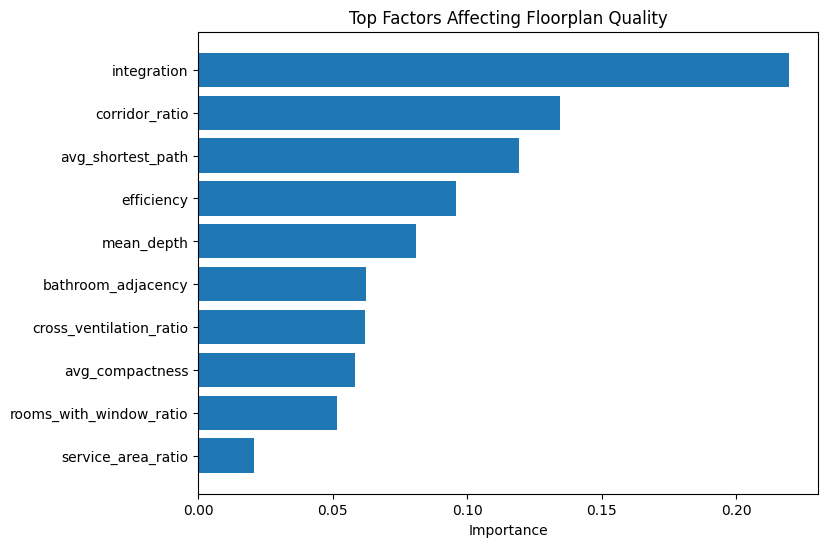

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top Factors Affecting Floorplan Quality")

plt.xlabel("Importance")

plt.show()